In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os

c:\Users\user\Desktop\Data_Science\venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
#Step 2 — Load & Preprocess MNIST

In [4]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize to [-1, 1]
x_train = (x_train - 127.5) / 127.5

# Reshape to (28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32')

BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices(x_train)\
    .shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

In [5]:
# Generator Model
# Architecture:
# Dense → BatchNorm → LeakyReLU → Conv2DTranspose → Tanh

In [6]:
def build_generator():
    model = tf.keras.Sequential()

    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))

    model.add(layers.Conv2DTranspose(128, (5,5), strides=(1,1),
                                     padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5,5), strides=(2,2),
                                     padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5,5), strides=(2,2),
                                     padding='same', use_bias=False,
                                     activation='tanh'))

    return model

In [7]:
# Discriminator Model
# Conv2D → LeakyReLU → Dropout → Flatten → Sigmoid

In [8]:
def build_discriminator():
    model = tf.keras.Sequential()

    model.add(layers.Conv2D(64, (5,5), strides=(2,2),
                            padding='same',
                            input_shape=[28,28,1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5,5), strides=(2,2),
                            padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

In [9]:
# Loss & Optimizer

In [10]:
cross_entropy = tf.keras.losses.BinaryCrossentropy()

generator = build_generator()
discriminator = build_discriminator()

generator_optimizer = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)

c:\Users\user\Desktop\Data_Science\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\Desktop\Data_Science\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Training Step
EPOCHS = 20
noise_dim = 100

gen_loss_history = []
disc_loss_history = []

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = cross_entropy(tf.ones_like(fake_output), fake_output)

        real_loss = cross_entropy(tf.ones_like(real_output), real_output)
        fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
        disc_loss = real_loss + fake_loss

    gradients_of_generator = gen_tape.gradient(
        gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(
        disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(
        zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(
        zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [12]:
# Image Visualization Function

In [13]:
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4,4))
    for i in range(predictions.shape[0]):
        plt.subplot(4,4,i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5,
                   cmap='gray')
        plt.axis('off')

    plt.show()

In [14]:
#Training Loop

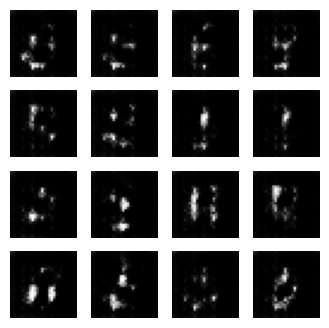

Epoch 1, Gen Loss: 0.6791943311691284, Disc Loss: 1.3511497974395752
Epoch 2, Gen Loss: 0.7026882767677307, Disc Loss: 1.3035235404968262
Epoch 3, Gen Loss: 0.6778700351715088, Disc Loss: 1.334181308746338
Epoch 4, Gen Loss: 0.7213444113731384, Disc Loss: 1.27485990524292
Epoch 5, Gen Loss: 0.5829765796661377, Disc Loss: 1.380267858505249


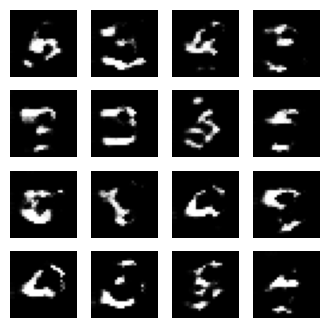

Epoch 6, Gen Loss: 0.9011906981468201, Disc Loss: 1.1978874206542969
Epoch 7, Gen Loss: 0.6783359050750732, Disc Loss: 1.31331205368042
Epoch 8, Gen Loss: 0.879621148109436, Disc Loss: 1.2102625370025635
Epoch 9, Gen Loss: 0.8705571889877319, Disc Loss: 1.3117468357086182
Epoch 10, Gen Loss: 0.8469552993774414, Disc Loss: 1.3457343578338623


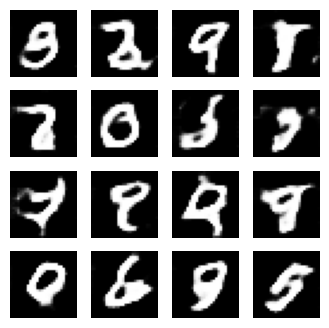

Epoch 11, Gen Loss: 0.6979698538780212, Disc Loss: 1.3043615818023682
Epoch 12, Gen Loss: 0.722711980342865, Disc Loss: 1.2726852893829346
Epoch 13, Gen Loss: 0.8629531860351562, Disc Loss: 1.3151421546936035
Epoch 14, Gen Loss: 1.1303589344024658, Disc Loss: 1.345332384109497
Epoch 15, Gen Loss: 0.8400960564613342, Disc Loss: 1.308539628982544


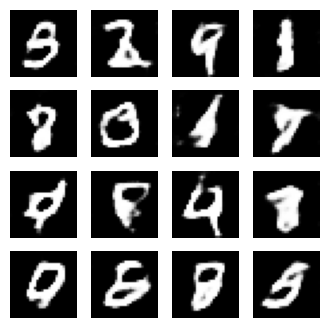

Epoch 16, Gen Loss: 0.8063554763793945, Disc Loss: 1.1642558574676514
Epoch 17, Gen Loss: 0.8146660923957825, Disc Loss: 1.3268736600875854
Epoch 18, Gen Loss: 0.7667071223258972, Disc Loss: 1.252645492553711
Epoch 19, Gen Loss: 0.6003462672233582, Disc Loss: 1.3921997547149658
Epoch 20, Gen Loss: 1.0194973945617676, Disc Loss: 1.2864553928375244


In [15]:
seed = tf.random.normal([16, noise_dim])

for epoch in range(EPOCHS):
    for image_batch in train_dataset:
        gen_loss, disc_loss = train_step(image_batch)

    gen_loss_history.append(gen_loss)
    disc_loss_history.append(disc_loss)

    if epoch % 5 == 0:
        generate_and_save_images(generator, epoch, seed)

    print(f"Epoch {epoch+1}, Gen Loss: {gen_loss}, Disc Loss: {disc_loss}")

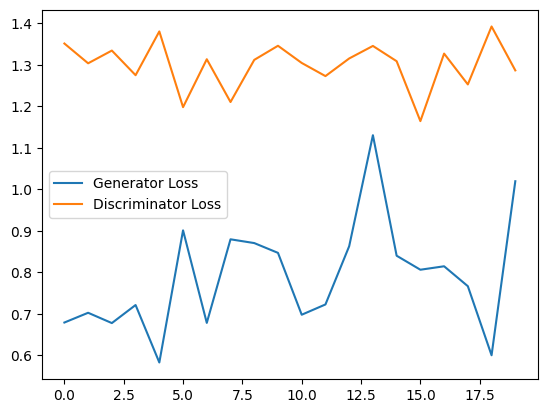

In [16]:
# loss graph
plt.plot(gen_loss_history, label='Generator Loss')
plt.plot(disc_loss_history, label='Discriminator Loss')
plt.legend()
plt.show()

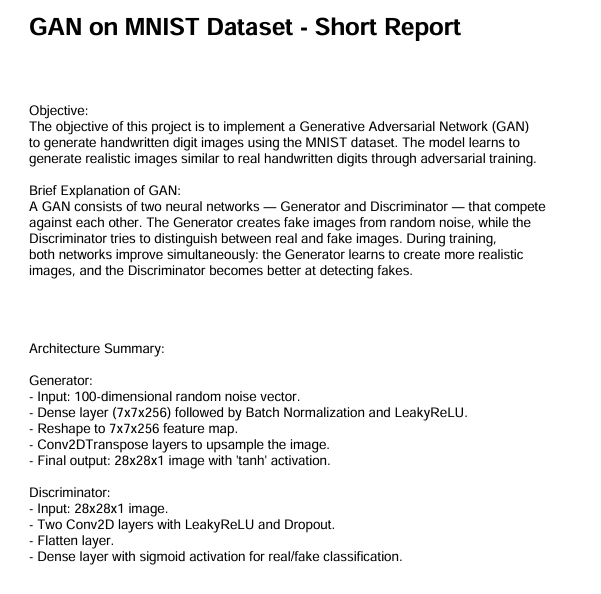

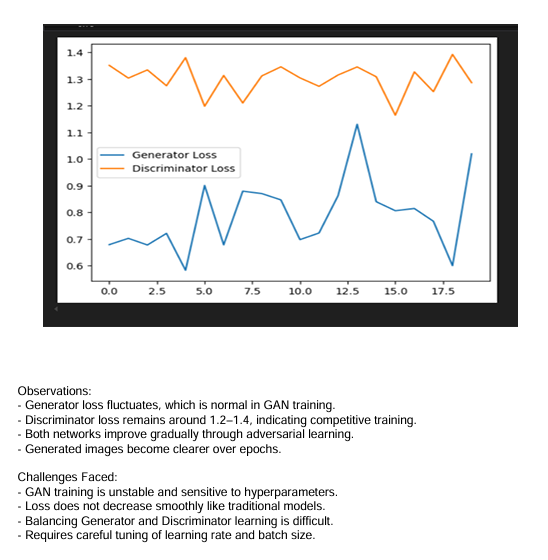